# التعامل مع الميزات العددية والوصفية في خط المعالجة

نتعلم في هذا الدرس: التعامل مع الميزات العددية والوصفية في خط المعالجة:

1. تعويض القيم المفقودة
2. توحيد القياس للميزات العددية
3. ترميز الميزات الوصفية

## 1. تحميل مجموعة البيانات

نحتاج إلى تعريف البيانات والهدف (target). هنا نبني نموذج انحدار (regression model).

In [7]:
from sklearn.datasets import fetch_openml

ames_housing = fetch_openml(name="house_prices", as_frame=True)
data = ames_housing.data
target = ames_housing.target

نستعرض الصفوف الأولى من إطار البيانات (dataframe).

In [8]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


### تحليل توزيع المتغير المستهدف

الخطوة الأولى في EDA لمشاكل الانحدار هي فحص توزيع المتغير المستهدف (`SalePrice`).
إذا كان التوزيع **ملتوياً (Skewed)**، فقد يؤثر ذلك سلباً على أداء النماذج الخطية (مثل SGDRegressor). في هذه الحالة، قد نحتاج إلى تحويله (مثلاً باستخدام اللوغاريتم `np.log1p`) لجعله أقرب إلى التوزيع الطبيعي.


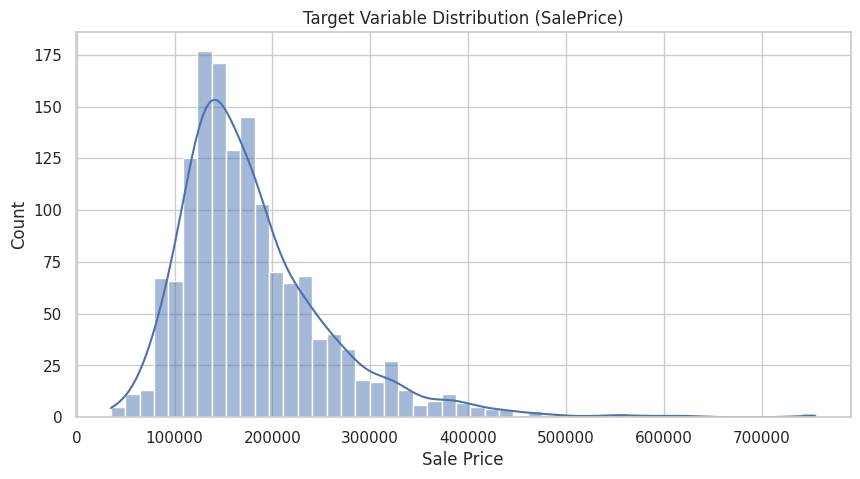

Skewness: 1.88


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# إعداد نمط الرسم
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(target, kde=True)
plt.title('Target Variable Distribution (SalePrice)')
plt.xlabel('Sale Price')
plt.show()

print(f"Skewness: {target.skew():.2f}")


## 2. أخذ مجموعة فرعية من الميزات

**من أجل البساطة**، يمكننا اختيار بعض الميزات (features) والاكتفاء بهذه المجموعة الفرعية من البيانات:

In [10]:
numeric_features = ["LotArea", "FullBath", "HalfBath"]
categorical_features = ["Neighborhood", "HouseStyle"]
data = data[numeric_features + categorical_features]

### التحقق من توازن الفئات (Categorical Imbalance)

من المهم جداً فحص المتغيرات الوصفية لمعرفة ما إذا كانت هناك فئات نادرة جداً.
وجود فئات نادرة قد يسبب مشاكل أثناء تقسيم البيانات (Train/Test Split) أو أثناء التحقق المتقاطع (Cross-Validation)، حيث قد تظهر الفئة في التدريب ولا تظهر في الاختبار، أو العكس.

**الحل:**
إذا وجدنا فئات نادرة، يمكننا دمجها في فئة "Other" أو استخدام معالجة قوية للأخطاء مثل `handle_unknown='ignore'` في `OneHotEncoder`.


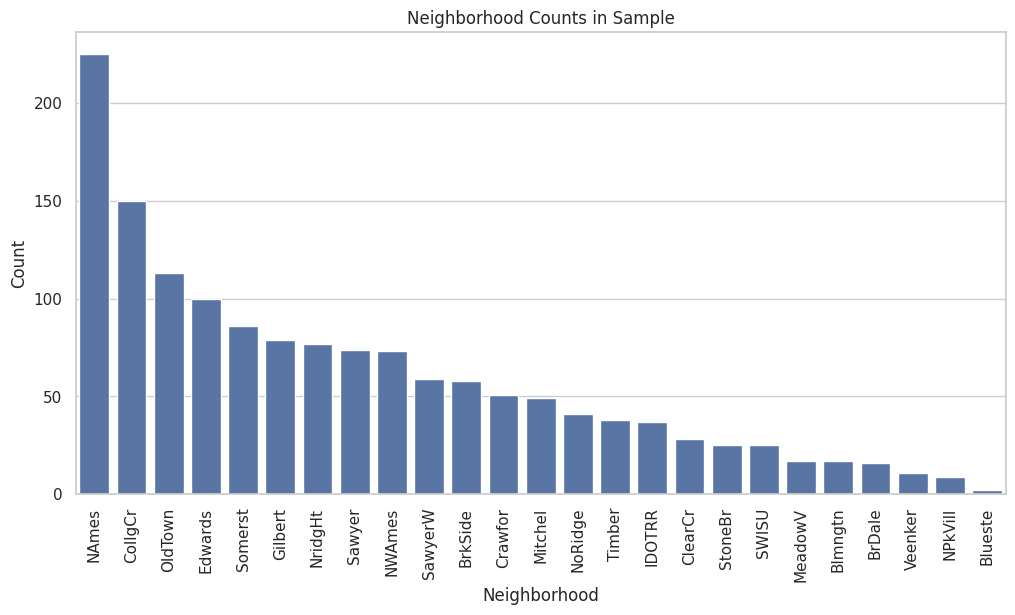

In [11]:
plt.figure(figsize=(12, 6))
neighborhood_counts = data['Neighborhood'].value_counts()
sns.barplot(x=neighborhood_counts.index, y=neighborhood_counts.values)
plt.xticks(rotation=90)
plt.title('Neighborhood Counts in Sample')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.show()

In [12]:
# عرض الفئات النادرة (أقل من 10 مرات ظهور في العينة)
rare_threshold = 10
rare_neighborhoods = neighborhood_counts[neighborhood_counts < rare_threshold]
print(f"Number of rare neighborhoods (< {rare_threshold}): {len(rare_neighborhoods)}")
print(rare_neighborhoods)

Number of rare neighborhoods (< 10): 2
Neighborhood
NPkVill    9
Blueste    2
Name: count, dtype: int64


## 3. المعالجة الأولية (Pre-processing)

نادراً ما تكون البيانات الخام جاهزة للاستخدام الفوري في نماذج تعلم الآلة. نحتاج غالباً إلى خطوات معالجة مثل:

- التعامل مع القيم المفقودة.
- ترميز المتغيرات الوصفية (Categorical Encoding).
- تقييس المتغيرات العددية (Scaling).

لنسهل الأمر، سنختر مجموعة محددة من الأعمدة للعمل عليها:

### أ. التعامل مع القيم المفقودة (Imputation)

القيم المفقودة مشكلة شائعة. لا تقبل معظم الخوارزميات وجود فراغات في البيانات.

**استراتيجيات التعويض (`SimpleImputer`):**

1. **`mean` (المتوسط):** تُستخدم مع البيانات العددية ذات التوزيع الطبيعي.
2. **`median` (الوسيط):** الأفضل للبيانات العددية التي تحتوي على قيم شاذة (Outliers).
3. **`most_frequent` (الأكثر تكراراً):** تُستخدم غالباً مع البيانات الوصفية (Categorical).
4. **`constant` (قيمة ثابتة):** تعويض القيمة المفقودة بقيمة محددة (مثلاً "Unknown" أو 0).

**كيف ندمجها في خط المعالجة؟**
عند استخدام `Pipeline`، نضمن أن عملية التعويض (`imputer.fit`) تتم فقط على بيانات التدريب، ثم تُطبق القواعد المستخلصة على بيانات الاختبار. هذا يمنع تسرب المعلومات.

#### 3.1 الميزات العددية

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

#### 3.2 الميزات الوصفية

In [14]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

## 4. ربط التحويلات بالميزات (والهدف)

ثلاث نقاط يجب تذكرها:

1. **محوّل الأعمدة (ColumnTransformer)** [رابط](https://scikit-learn.org/stable/modules/compose.html#column-transformer) يُستخدم لاختيار الميزات التي تُطبَّق عليها التحويلات المحددة.
2. **اتحاد الميزات (FeatureUnion)** [رابط](https://scikit-learn.org/stable/modules/compose.html#feature-union) يربط مخرجات المحوّلات في فضاء ميزات مركّب (composite feature space).
3. أخيراً، لتحويل الهدف (target) (مثلاً تحويل لوغاريتمي لـ y) استخدم **متنبئ الهدف المحوّل (TransformedTargetRegressor)** [رابط](https://scikit-learn.org/stable/modules/compose.html#transformed-target-regressor).

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 5. تعريف المسار

تعريف نموذج الانحدار (regression model).

أحياناً نسمّي المسار بالكامل **النموذج (model)**. لذلك نسمي المتنبئ (predictor) بهذا الاسم.

In [16]:
from sklearn.linear_model import SGDRegressor

predictor = SGDRegressor(loss="squared_error")

ربط الخطوات بالمتنبئ (predictor).

In [17]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## قياس التعميم

أحد أهم المفاهيم في تعلم الآلة هو قدرة النموذج على **التعميم (Generalization)**، أي أداؤه على بيانات جديدة لم يرها أثناء التدريب.

يقع الكثير من المبتدئين في خطأ فادح وهو تقييم النموذج على نفس البيانات التي تدرب عليها. هذا يعطي نتائج مضللة وتفاؤلية جداً.

In [18]:
# WRONG
# model.fit(data, target)

### وضع مجموعة للاختبار

يجب تقسيم البيانات إلى قسمين:

1. **مجموعة التدريب (Training Set):** تُستخدم لتدريب النموذج.
2. **مجموعة الاختبار (Test Set):** تُحجب عن النموذج تماماً، وتُستخدم فقط في النهاية لتقييم أدائه.

In [19]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات: 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (1168, 5)
Shape of X_test: (292, 5)


والآن: الملاءمة، لاحظ كيف يتغيّر لون الرسم بعد التدريب.

In [20]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

**إضافة**: يمكننا بدلاً من ذلك استخدام واجهة الدوال (functional API): `make_column_transformer` و `make_pipeline`، ولا تتطلبان ولا تسمحان بتسمية المُقدّرات يدوياً؛ بل تُعيَّن أسماؤها تلقائياً بأحرف صغيرة من أنواعها.


```python
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"), StandardScaler()
)
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
)
model = make_pipeline(preprocessor, SGDRegressor())
model.fit(X_train, y_train)
```

## 6. تقييم الأداء على بيانات الاختبار

In [21]:
score = model.score(X_test, y_test)
print(f"R² Score on Test Set: {score:.3f}")

R² Score on Test Set: 0.663


ملاحظة: **تقييم النموذج (Model Evaluation)** يحتاج نقاشاً مستقلاً، لكن نعرضه هنا للتكميل.

---

للمزيد انظر: [Predictive machine learning pipeline with mixed data types](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html).